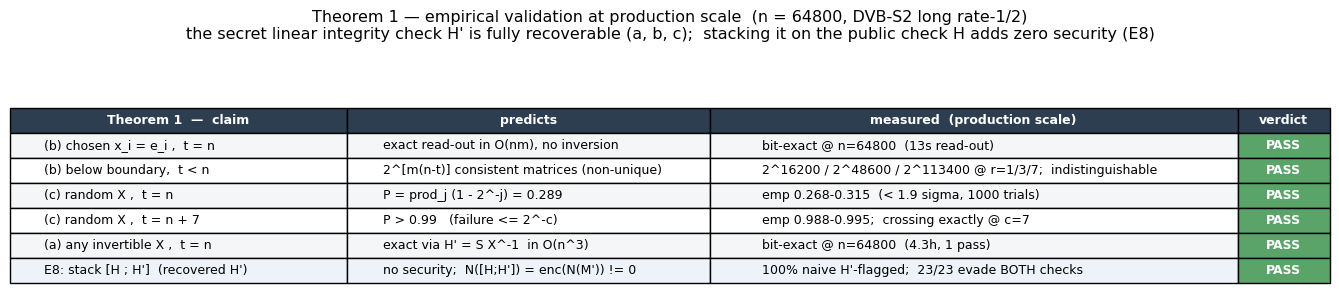

In [5]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

E7a = json.load(open("runs_e7/e7a_n64800.json"))
E7b = json.load(open("runs_e7/e7b_qpochhammer.json"))
E7p = json.load(open("runs_e7/e7_prod_n64800.json"))
chans = [d for d in (json.load(open(p)) for p in sorted(Path("runs_e8").glob("*.json"))) if "labels" in d]
E8 = json.load(open("runs_e8/_summary.json"))
r1 = next(w for w in E7a["nonuniqueness_witnesses"] if w["r"] == 1)["log2_consistent_matrices"]
c0 = [next(p for p in cur if p["c"] == 0)["p_emp"] for cur in E7b["curves"].values()]
c7 = [next(p for p in cur if p["c"] == 7)["p_emp"] for cur in E7b["curves"].values()]
qp = E7b["qpochhammer_constant"]
n_ch  = sum(any(l.get("attackable") and l.get("evading_E2") for l in c["labels"]) for c in chans)
naive_pct = int(round(E8["naive_frac_flagged_by_Hprime_mean"] * 100))
rows = [["(b) chosen x_i = e_i ,  t = n", "exact read-out in O(nm), no inversion", f"bit-exact @ n=64800  ({E7a['readout_seconds']:.0f}s read-out)", "PASS"], ["(b) below boundary,  t < n", "2^[m(n-t)] consistent matrices (non-unique)", f"2^{r1} / 2^48600 / 2^113400 @ r=1/3/7;  indistinguishable", "PASS"], ["(c) random X ,  t = n", f"P = prod_j (1 - 2^-j) = {qp:.3f}", f"emp {min(c0):.3f}-{max(c0):.3f}  (< 1.9 sigma, 1000 trials)", "PASS"], ["(c) random X ,  t = n + 7", "P > 0.99   (failure <= 2^-c)", f"emp {min(c7):.3f}-{max(c7):.3f};  crossing exactly @ c=7", "PASS"], ["(a) any invertible X ,  t = n", "exact via H' = S X^-1  in O(n^3)", f"bit-exact @ n=64800  ({E7p['recover_seconds']/3600:.1f}h, 1 pass)", "PASS"], ["E8: stack [H ; H']  (recovered H')", "no security;  N([H;H']) = enc(N(M')) != 0", f"{naive_pct}% naive H'-flagged;  {n_ch}/{n_ch} evade BOTH checks", "PASS"]]
fig, ax = plt.subplots(figsize=(13.5, 2.7)); ax.axis("off")
col = ["Theorem 1  —  claim", "predicts", "measured  (production scale)", "verdict"]
tbl = ax.table(cellText=rows, colLabels=col, cellLoc="left", loc="center", colWidths=[0.255, 0.275, 0.40, 0.07])
tbl.auto_set_font_size(False); tbl.set_fontsize(9.0); tbl.scale(1, 1.62)
for j in range(4):
    c = tbl[0, j]; c.set_facecolor("#2c3e50"); c.set_text_props(color="white", fontweight="bold")
for i in range(1, len(rows) + 1):
    tbl[i, 3].set_facecolor("#5aa469"); tbl[i, 3].set_text_props(color="white", fontweight="bold", ha="center")
    for j in range(3):
        tbl[i, j].set_facecolor("#f4f6f8" if i % 2 else "#ffffff")
    if i == len(rows):
        for j in range(3): tbl[i, j].set_facecolor("#eef3fa")
fig.suptitle("Theorem 1 — empirical validation at production scale  (n = 64800, DVB-S2 long rate-1/2)\n" "the secret linear integrity check H' is fully recoverable (a, b, c);  stacking it on the public check H adds zero security (E8)", fontsize=11.5, y=1.10)
plt.tight_layout(); plt.show()

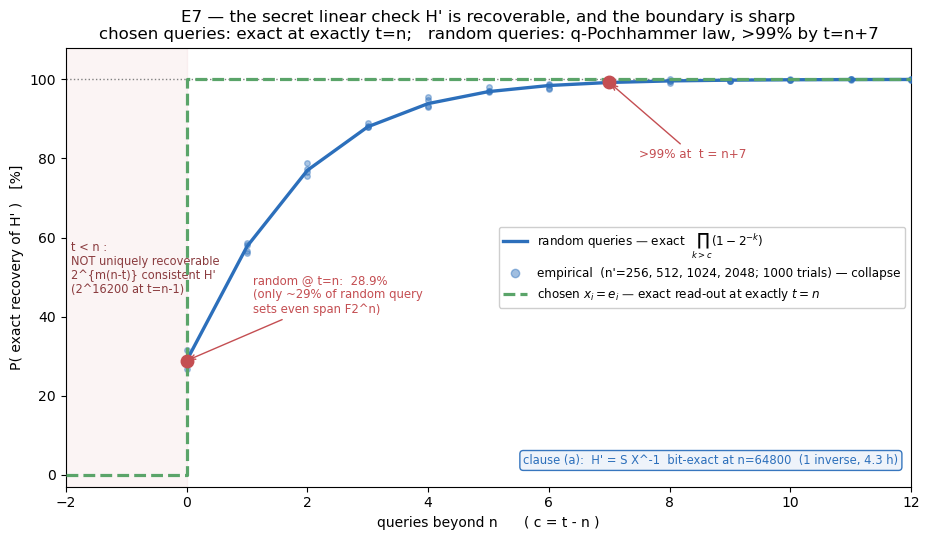

In [6]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
E7b = json.load(open("runs_e7/e7b_qpochhammer.json"))
E7p = json.load(open("runs_e7/e7_prod_n64800.json"))
curves = E7b["curves"]; ns = sorted(int(k) for k in curves); CMAX = 12
def Pexact(c):
    if c < 0: return 0.0
    p = 1.0
    for k in range(c + 1, c + 200): p *= (1 - 2.0 ** -k)
    return p
fig, ax = plt.subplots(figsize=(9.4, 5.5))
cc = np.arange(-2, CMAX + 1); exact = np.array([Pexact(int(c)) for c in cc]) * 100
ax.plot(cc[cc >= 0], exact[cc >= 0], "-", color="#2c6fbb", lw=2.4, zorder=4, label=r"random queries — exact  $\prod_{k>c}(1-2^{-k})$")
for nn in ns:
    pts = {p["c"]: p["p_emp"] for p in curves[str(nn)]}
    xs = [c for c in cc if c in pts and c >= 0]
    ax.plot(xs, [pts[c] * 100 for c in xs], "o", color="#2c6fbb", ms=4, alpha=0.40, zorder=3)
ax.plot([], [], "o", color="#2c6fbb", alpha=0.45, label=f"empirical  (n'={', '.join(map(str, ns))}; 1000 trials) — collapse")
ax.step([-2, 0, CMAX], [0, 100, 100], where="post", color="#5aa469", lw=2.3, ls="--", zorder=5, label=r"chosen $x_i=e_i$ — exact read-out at exactly $t=n$")
ax.plot(0, 28.88, "o", color="#c44e52", ms=9, zorder=6)
ax.annotate("random @ t=n:  28.9%\n(only ~29% of random query\nsets even span F2^n)", xy=(0, 28.88), xytext=(1.1, 41), fontsize=8.4, color="#c44e52", arrowprops=dict(arrowstyle="->", color="#c44e52"))
ax.plot(7, 99.22, "o", color="#c44e52", ms=9, zorder=6)
ax.annotate(">99% at  t = n+7", xy=(7, 99.22), xytext=(7.5, 80), fontsize=8.6, color="#c44e52", arrowprops=dict(arrowstyle="->", color="#c44e52"))
ax.axvspan(-2, 0, color="#c44e52", alpha=0.06, zorder=0)
ax.text(-1.92, 52, "t < n :\nNOT uniquely recoverable\n2^{m(n-t)} consistent H'\n(2^16200 at t=n-1)", fontsize=8.2, color="#8a3b3e", va="center", ha="left")
ax.set_xlabel("queries beyond n      ( c = t - n )"); ax.set_ylabel("P( exact recovery of H' )   [%]")
ax.set_xlim(-2, CMAX); ax.set_ylim(-3, 108); ax.axhline(100, color="gray", ls=":", lw=1)
ax.set_title("E7 — the secret linear check H' is recoverable, and the boundary is sharp\n" "chosen queries: exact at exactly t=n;   random queries: q-Pochhammer law, >99% by t=n+7")
ax.legend(fontsize=8.6, loc="center right", framealpha=0.96)
ax.text(0.985, 0.045, f"clause (a):  H' = S X^-1  bit-exact at n=64800  (1 inverse, {E7p['recover_seconds']/3600:.1f} h)", transform=ax.transAxes, ha="right", va="bottom", fontsize=8.3, color="#2c6fbb", bbox=dict(boxstyle="round", fc="#eef3fa", ec="#2c6fbb", alpha=0.95))
plt.tight_layout(); plt.show()

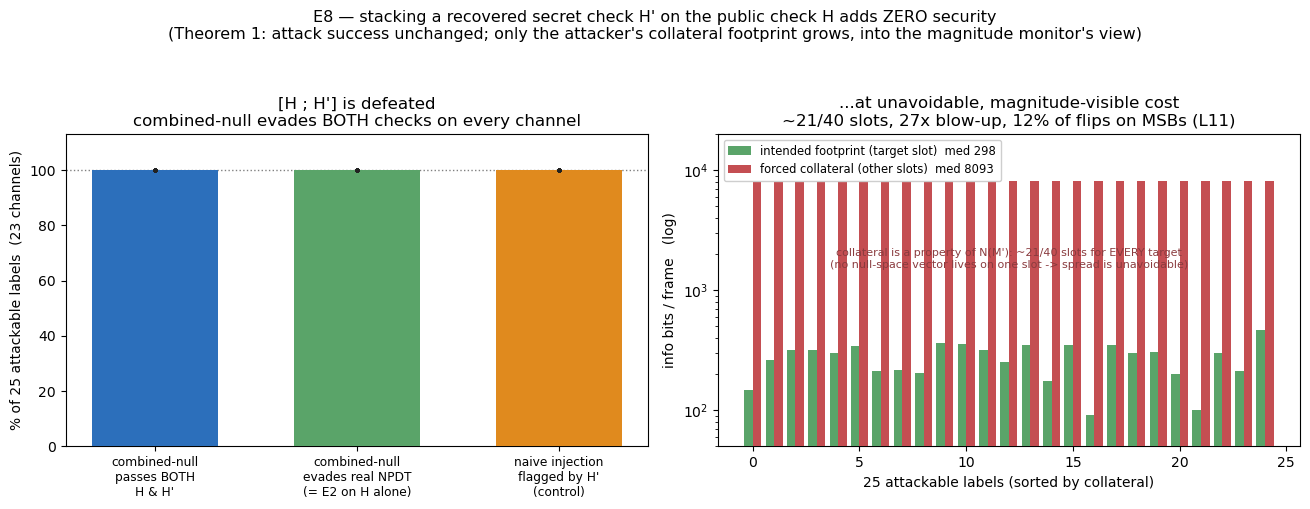

In [7]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

chans = [d for d in (json.load(open(p)) for p in sorted(Path("runs_e8").glob("*.json"))) if "labels" in d]
labs = [l for c in chans for l in c["labels"] if l.get("attackable") and l.get("evading_E2")]
n_lab = len(labs)
n_ch = sum(any(l.get("attackable") and l.get("evading_E2") for l in c["labels"]) for c in chans)
demo = next((l["demo"] for c in chans for l in c["labels"] if l.get("attackable") and "demo" in l), None)
A = lambda key: np.array([l["aggregate"][key] for l in labs], float)
pass_both, naive_fl, foot_ex = A("frac_combined_passes_both")*100, A("frac_naive_flagged_by_combined")*100, A("frac_footprint_exact")*100
slots, coll_w, wt_tgt = A("n_slots_touched_med"), A("collateral_info_weight_med"), A("window_weight_med")
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.2, 4.8))
metrics = [("combined-null\npasses BOTH\nH & H'", pass_both, "#2c6fbb"), ("combined-null\nevades real NPDT\n(= E2 on H alone)", foot_ex, "#5aa469"), ("naive injection\nflagged by H'\n(control)", naive_fl, "#e08a1e")]
for i, (lab, vals, c) in enumerate(metrics):
    axL.bar(i, vals.mean(), 0.62, color=c, zorder=3)
    axL.plot(np.full_like(vals, i), vals, ".", color="#222", ms=4, alpha=0.5, zorder=4)
axL.set_xticks(range(3)); axL.set_xticklabels([m[0] for m in metrics], fontsize=8.8)
axL.set_ylabel(f"% of {n_lab} attackable labels  ({n_ch} channels)")
axL.set_ylim(0, 113); axL.axhline(100, color="gray", ls=":", lw=1)
axL.set_title("[H ; H'] is defeated\ncombined-null evades BOTH checks on every channel")
order = np.argsort(coll_w); x = np.arange(n_lab)
axR.bar(x - 0.2, np.maximum(wt_tgt[order], 1), 0.4, color="#5aa469", zorder=3, label=f"intended footprint (target slot)  med {int(np.median(wt_tgt))}")
axR.bar(x + 0.2, coll_w[order], 0.4, color="#c44e52", zorder=3, label=f"forced collateral (other slots)  med {int(np.median(coll_w))}")
axR.set_yscale("log"); axR.set_ylim(50, 2e4); axR.set_ylabel("info bits / frame   (log)")
axR.set_xlabel(f"{n_lab} attackable labels (sorted by collateral)")
blow = np.median(coll_w) / max(1, np.median(wt_tgt))
msb = f"{demo['heaviest_window_collateral_msb_fraction']*100:.0f}%" if demo else "~12%"
axR.set_title(f"...at unavoidable, magnitude-visible cost\n" f"~{int(np.median(slots))}/40 slots, {blow:.0f}x blow-up, {msb} of flips on MSBs (L11)")
axR.legend(fontsize=8.3, loc="upper left", framealpha=0.95)
axR.text(0.5, 0.60, "collateral is a property of N(M'): ~21/40 slots for EVERY target\n" "(no null-space vector lives on one slot -> spread is unavoidable)", transform=axR.transAxes, ha="center", va="center", fontsize=8.0, color="#8a3b3e")
fig.suptitle("E8 — stacking a recovered secret check H' on the public check H adds ZERO security\n" "(Theorem 1: attack success unchanged; only the attacker's collateral footprint grows, into the magnitude monitor's view)", fontsize=11.5, y=1.05)
plt.tight_layout(); plt.show()